In [1]:
%reload_ext autoreload
%autoreload 2
from collections.abc import Iterable
import os
from pathlib import Path
import sys
from typing import Any, Literal

from matplotlib.axes import Axes
from matplotlib.colors import LogNorm, Normalize
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
import numpy as np
from qecbench import TaskStats

import plot_utils

# Add parent directory to the path
sys.path.insert(0, os.path.abspath(".."))

from utils import get_csv_path

%matplotlib inline
plt.rcParams.update({"pdf.fonttype": 42})

In [2]:
LIST_NUM_RELAYS = [1, 2, 4, 8, 16]
LIST_NUM_CHAINS = [1, 2, 4, 8, 16]

# Helper functions

In [3]:
def _build_grids(
    stats: Iterable[TaskStats],
    *,
    error_rate: float,
    all_num_chains: list[int],
    all_num_relays: list[int],
    fr_mode: Literal["per_shot", "per_round"],
) -> tuple[np.ndarray, np.ndarray]:
    """Failure rate grid and average iteration grid over (num_chains x num_relays); missing cells are NaN."""
    fr_grid = np.full((len(all_num_chains), len(all_num_relays)), np.nan)
    iter_grid = np.full((len(all_num_chains), len(all_num_relays)), np.nan)
    for s in stats:
        m = s.metadata
        if m.error_rate != error_rate:
            continue
        nc = m.decoder_params["num_chains"]
        nr = m.decoder_params["num_relays"]
        yi, xi = all_num_chains.index(nc), all_num_relays.index(nr)
        assert np.isnan(fr_grid[yi, xi]) and np.isnan(iter_grid[yi, xi])
        fr = s.failure_rate
        if fr_mode == "per_round":
            fr = plot_utils.shot_error_rate_to_piece_error_rate(
                fr, pieces=m.circuit_params["rounds"]
            )
        fr_grid[yi, xi] = fr
        iter_grid[yi, xi] = s.avg_iters
    return fr_grid, iter_grid


def _highlight_row(ax: Axes, row_index: int, ncols: int) -> None:
    """Draw a crimson rectangle around row ``row_index`` of an imshow heatmap."""
    rect = Rectangle(
        (-0.5, row_index - 0.5),
        ncols,
        1,
        fill=False,
        edgecolor="red",
        linewidth=4,
        linestyle="--",
        clip_on=False,
        zorder=10,
    )
    ax.add_patch(rect)


def plot_heatmap(
    *,
    circuit_name: str,
    circuit_params: dict[str, Any],
    multirelaybp_fixed_params: dict[str, Any],
    error_rates: list[float],
    all_num_relays: list[int],
    all_num_chains: list[int],
    fr_mode: Literal["per_shot", "per_round"],
    suptitle: str | None = None,
    save_at: str | Path | None = None,
):
    # row 0: failure-rate heatmaps (shared LogNorm across the row)
    # row 1: avg-iter heatmaps (shared linear Normalize across the row)
    # column: one for each error rate
    # within each Axes: num_chains (rows) x num_relays (cols) heatmap
    if 1 not in all_num_chains:
        raise ValueError("all_num_chains must include 1 to highlight the RelayBP row")
    highlight_row_idx = all_num_chains.index(1)

    stats = list(
        plot_utils.load_stats(
            get_csv_path(circuit_name, circuit_params, "MultiRelayBP"),
            error_rates=error_rates,
            decoder_fixed_params=multirelaybp_fixed_params,
            decoder_flex_params={
                "num_relays": all_num_relays,
                "num_chains": all_num_chains,
            },
        )
    )

    fr_grids: list[np.ndarray] = []
    iter_grids: list[np.ndarray] = []
    for error_rate in error_rates:
        fg, ig = _build_grids(
            stats,
            error_rate=error_rate,
            all_num_chains=all_num_chains,
            all_num_relays=all_num_relays,
            fr_mode=fr_mode,
        )
        fr_grids.append(fg)
        iter_grids.append(ig)

    # FR shared LogNorm across the top row.
    fr_finite = np.concatenate([g[np.isfinite(g)] for g in fr_grids])
    if fr_finite.size == 0:
        print("No FR data found for the requested parameters; nothing to plot.")
        return
    fr_vmin, fr_vmax = float(fr_finite.min()), float(fr_finite.max())
    if fr_vmin == fr_vmax:
        fr_vmin, fr_vmax = fr_vmin / 2, fr_vmax * 2
    fr_norm = LogNorm(vmin=fr_vmin, vmax=fr_vmax)

    # Avg-iter shared linear Normalize across the bottom row.
    iter_finite = np.concatenate([g[np.isfinite(g)] for g in iter_grids])
    if iter_finite.size == 0:
        print("No avg-iter data found for the requested parameters; nothing to plot.")
        return
    iter_vmin, iter_vmax = float(iter_finite.min()), float(iter_finite.max())
    if iter_vmin == iter_vmax:
        iter_vmin, iter_vmax = iter_vmin - 1, iter_vmax + 1
    iter_norm = Normalize(vmin=iter_vmin, vmax=iter_vmax)

    nrows, ncols = 2, len(error_rates)
    fig, axs = plt.subplots(
        nrows,
        ncols,
        figsize=(3 * ncols + 1, 3 * nrows),
        squeeze=False,
        layout="constrained",
    )

    for col, error_rate in enumerate(error_rates):
        im_fr = plot_utils.plot_heatmap(
            fr_grids[col],
            axs[0][col],
            x_values=all_num_relays,
            y_values=all_num_chains,
            norm=fr_norm,
            ylabel=("#chains" if col == 0 else None),
            annotation_fmt=lambda x: f"{x:.3f}" if x >= 0.01 else f"{x:.1e}",
        )
        _highlight_row(axs[0][col], highlight_row_idx, len(all_num_relays))

        im_iter = plot_utils.plot_heatmap(
            iter_grids[col],
            axs[1][col],
            x_values=all_num_relays,
            y_values=all_num_chains,
            norm=iter_norm,
            xlabel="#relays",
            ylabel=("#chains" if col == 0 else None),
            annotation_fmt=lambda x: f"{x:.1f}",
        )
        _highlight_row(axs[1][col], highlight_row_idx, len(all_num_relays))

    cbar_fr = fig.colorbar(im_fr, ax=axs[0].tolist(), fraction=0.046, pad=0.02)
    cbar_fr.ax.tick_params(labelsize=14)
    cbar_iter = fig.colorbar(im_iter, ax=axs[1].tolist(), fraction=0.046, pad=0.02)
    cbar_iter.ax.tick_params(labelsize=14)

    # Metric names as row titles to the left of the leftmost Axes.
    ax: Axes
    for ax, text in [(axs[0][0], "Failure Rate"), (axs[1][0], "Avg. Iter")]:
        ax.annotate(
            text,
            xy=(0, 0.5),
            xytext=(-20, 0),
            xycoords=ax.yaxis.label,
            textcoords="offset points",
            ha="center",
            va="center",
            rotation=90,
            fontsize=plot_utils.LABEL_FONTSIZE,
            fontweight="bold",
        )
    # Error rates as column titles above the upper row of Axes.
    for ax, error_rate in zip(axs[0], error_rates):
        ax.annotate(
            f"p = {error_rate:g}",
            xy=(0.5, 1),
            xytext=(0, 20),
            xycoords="axes fraction",
            textcoords="offset points",
            ha="center",
            va="center",
            fontsize=plot_utils.LABEL_FONTSIZE,
            fontweight="bold",
        )

    if suptitle:
        fig.suptitle(suptitle, fontsize=plot_utils.SUPTITLE_FONTSIZE)
    if save_at:
        fig.savefig(save_at, bbox_inches="tight")
    plt.show()

# RotatedSurfaceCode_Circuit, basis=Z, d=11, rounds=11

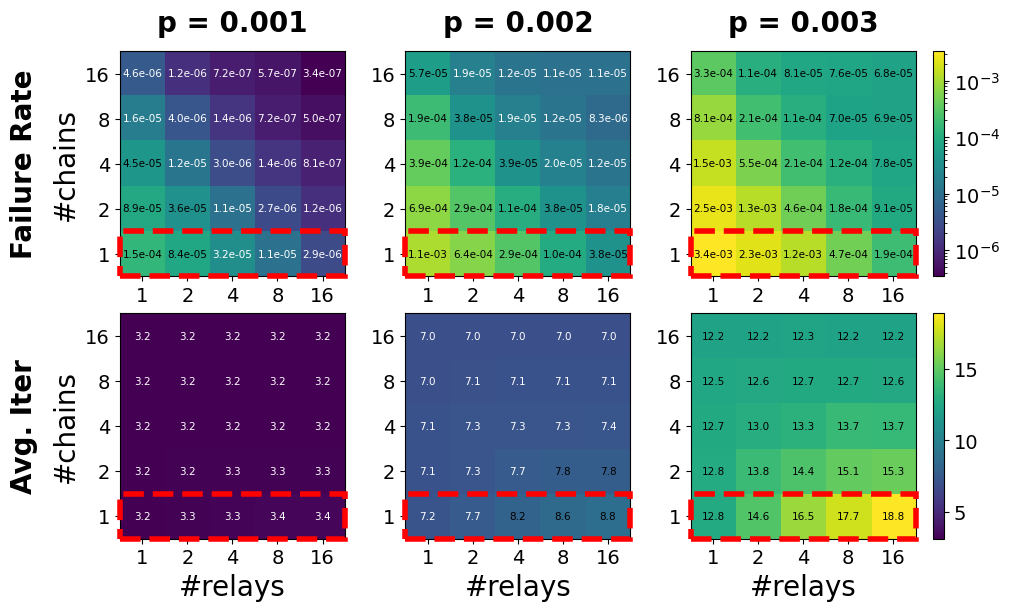

In [4]:
circuit_name = "RotatedSurfaceCode_Circuit"
circuit_params = {"basis": "Z", "d": 11, "rounds": 11}
error_rates = [0.001, 0.002, 0.003]

multirelaybp_fixed_params = {
    "gamma0": 0.55,
    "gamma_dist_interval": (-0.2944735403909491, 0.9444054073490704),
    "pre_iter": 50,
    "max_iter_per_relay": 50,
    "stop_nconv": 1,
}

plot_heatmap(
    circuit_name=circuit_name,
    circuit_params=circuit_params,
    multirelaybp_fixed_params=multirelaybp_fixed_params,
    error_rates=error_rates,
    all_num_relays=LIST_NUM_RELAYS,
    all_num_chains=LIST_NUM_CHAINS,
    fr_mode="per_round",
    save_at="heatmap-RSC_Circuit.pdf",
)

# RotatedSurfaceCode_Phenom, basis=Z, d=11, rounds=11

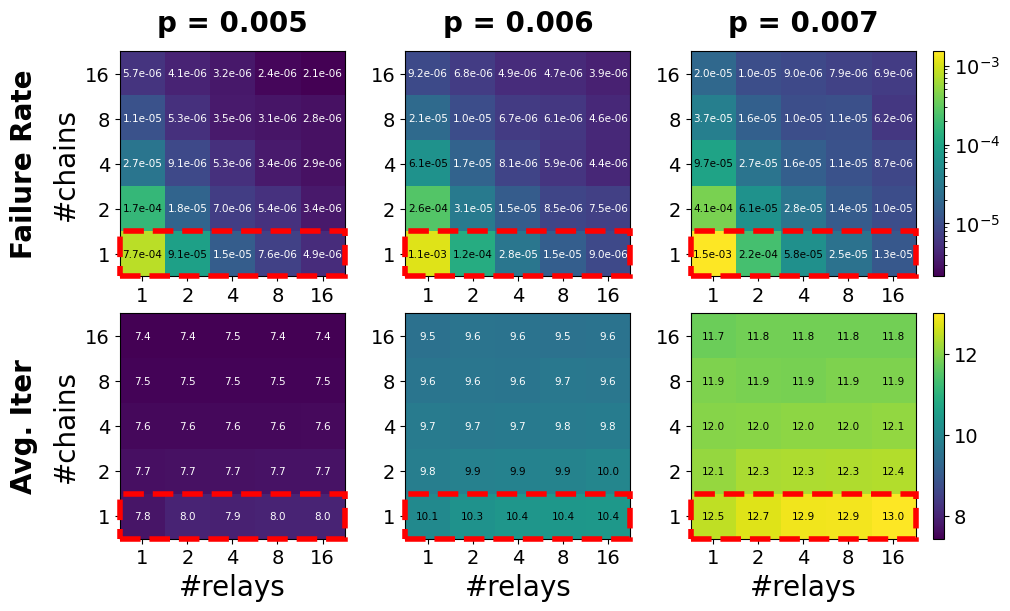

In [5]:
circuit_name = "RotatedSurfaceCode_Phenom"
circuit_params = {"basis": "Z", "d": 11, "rounds": 11}
error_rates = [0.005, 0.006, 0.007]

multirelaybp_fixed_params = {
    "gamma0": 0.65,
    "gamma_dist_interval": (-0.2241259276391633, 0.5608805426310253),
    "max_iter_per_relay": 50,
    "pre_iter": 50,
    "stop_nconv": 1,
}

plot_heatmap(
    circuit_name=circuit_name,
    circuit_params=circuit_params,
    multirelaybp_fixed_params=multirelaybp_fixed_params,
    error_rates=error_rates,
    all_num_relays=LIST_NUM_RELAYS,
    all_num_chains=LIST_NUM_CHAINS,
    fr_mode="per_round",
    save_at="heatmap-RSC_Phenom.pdf",
)

# BB_144_12_12_Circuit, basis=Z, rounds=12

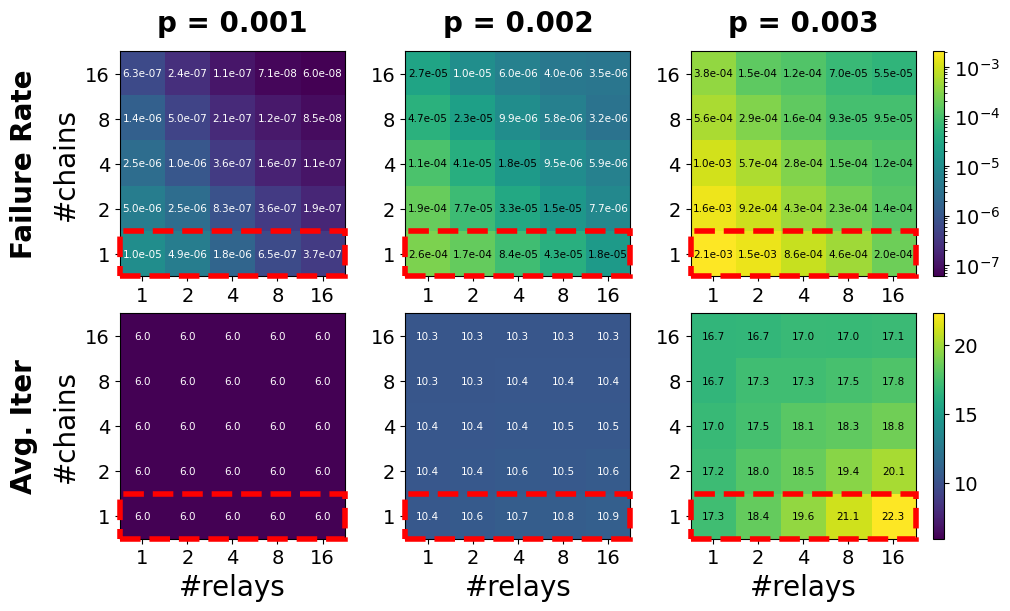

In [6]:
circuit_name = "BB_144_12_12_Circuit"
circuit_params = {"basis": "Z", "rounds": 12}
error_rates = [0.001, 0.002, 0.003]

multirelaybp_fixed_params = {
    "gamma0": 0.2,
    "gamma_dist_interval": (-0.19806670996164882, 0.6200937872049607),
    "max_iter_per_relay": 50,
    "pre_iter": 50,
    "stop_nconv": 1,
}

plot_heatmap(
    circuit_name=circuit_name,
    circuit_params=circuit_params,
    multirelaybp_fixed_params=multirelaybp_fixed_params,
    error_rates=error_rates,
    all_num_relays=LIST_NUM_RELAYS,
    all_num_chains=LIST_NUM_CHAINS,
    fr_mode="per_round",
    save_at="heatmap-BB_Circuit.pdf",
)